# 45度端面マルチモードファイバの光伝搬

## 順方向・逆方向コードの実際のアルゴリズムと数式

入力ベクトル場から境界、ファイバ内部、出射面、カメラ記録までを説明する。既に確認したコードのスナップショットに基づく実装解析であり、新たな全光線シミュレーションの実行結果ではない。

**解析対象**

- [angled45/mmf_angled45_main.py](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py)
- [angled45/mmf_angled45_reverse_main.py](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py)

**解析対象コミット**: [c6a399ce07fd095daee3bedfee1fb04ccac07f4d](https://github.com/z-labo/Raytracing/commit/c6a399ce07fd095daee3bedfee1fb04ccac07f4d)

**形式変更日**: 2026-09-17

## 本書の読み方

各節の出典リンクは解析対象コミットの該当コード行へ移動する。説明と数式はMarkdownセルに格納し、表示数式は全て`$$`で囲んだLaTeXとする。本ノートブックは解説文書のため、実行するコードセルはない。図はファイル内に埋め込まれており、別の画像ファイルを必要としない。非公開リポジトリのリンクを開くにはGitHubへのログインと閲覧権限が必要である。

## 目次

- [1 実装の要点と実行順序](#section-01)
- [2 光学系の数値と座標](#section-02)
- [3 順方向入力ベクトル場の実際の生成](#section-03)
- [4 光線の交点と境界媒質](#section-04)
- [5 入射面と境界でのSnell則とFresnel処理](#section-05)
- [6 ファイバ内部の位相と偏光伝搬](#section-06)
- [7 確率的分岐とコヒーレントMonte Carlo](#section-07)
- [8 45度端面から側方へ出る経路](#section-08)
- [9 出射光線を側面基準面へ集める方法](#section-09)
- [10 有限画素での複素場と強度の加算](#section-10)
- [11 基準面からカメラまでのベクトル角スペクトル法](#section-11)
- [12 逆方向点光源のベクトル場と面積標本化](#section-12)
- [13 逆方向の境界通過と出射面記録](#section-13)
- [14 選択可能なanalytic入力分岐](#section-14)
- [15 順方向と逆方向の対応と限界](#section-15)
- [16 結果を解釈するときの確認事項](#section-16)

## 記号と単位

| 記号 | 意味 |
| --- | --- |
| E, H | 複素電場と相対単位の磁場 |
| k̂, k₀, λ₀ | 単位進行方向、真空波数、真空波長 |
| L, a, Δ | ファイバ軸上長、コア半径、格子間隔 |
| W, N₀, * | 重要度重み、総発射数、複素共役 |
| f / r | 順方向 / 逆方向の座標 |
| u, v, w | 側面の右手系局所基底 |

<a id="section-01"></a>

## 1 実装の要点と実行順序

**出典**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S04 · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233) · [S17 · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136)

両プログラムは同じ45度端面ファイバを互いに反対側から伝搬させる。現在の既定動作では、まずreverseが平坦端面の直外における方向別の複素電場を保存し、mainがそのチャネルを位相共役して反対向きに再入射させる。main内のdefine_input_vector_fieldは既定動作の入力源ではなく、INPUT_MODEをanalyticに変更したときに使用される。

計算は三つの処理を接続している。境界間では幾何光学の直線光線を追跡し、その経路に3成分の複素電場、Fresnel振幅、光路位相を付与する。出射光線は有限画素にコヒーレント加算する。順方向では、この基準面場をFFTによるベクトル角スペクトル法で側面カメラまで伝搬させる。ファイバ内部を格子化してMaxwell方程式を直接解く処理や、導波モードの固有値展開は、この既定呼出し経路にはない。

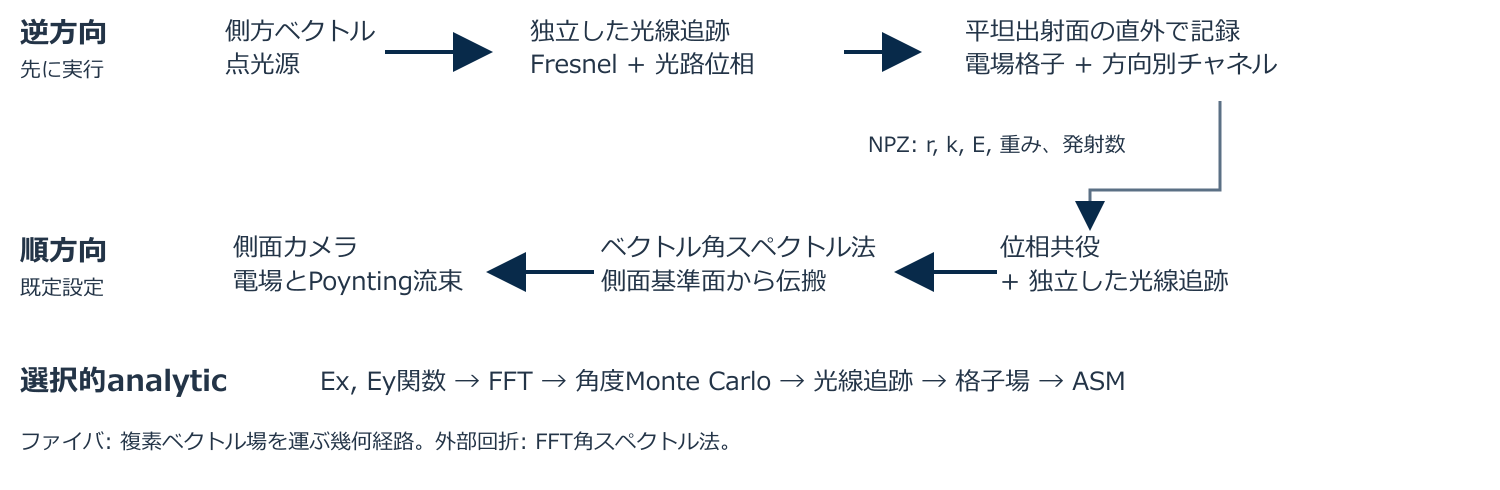

*図1. 実際の実行順序。既定設定では逆方向計算でチャネルを保存し、順方向で位相共役して再入射させる。*

本書の式は、各節にリンクした実装の演算を数式化したものである。既定値から導いた数値は計算値であり、新たな光線シミュレーションの測定結果ではない。各節の出典は解析対象コミットに固定したGitHubの行リンクである。

<a id="section-02"></a>

## 2 光学系の数値と座標

**出典**: [S02 · L6–L33](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_parameters.py#L6-L33) · [S03 · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28) · [S06 · L11–L103](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled_geometry.py#L11-L103) · [S17 · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136)

| 項目 | 現在値 |
| --- | --- |
| 真空波長 | 0.633 μm = 0.000633 mm |
| 屈折率 | core 1.4469   clad 1.3001   outside 1.0 |
| コアとクラッド半径 | 0.0525 mm / 0.0625 mm |
| 軸上の端面中心 | L = 3.6 mm |
| 端面角と方位角 | 45° / 0° |
| 順方向の目標点 | (−0.1625, 0, 3.6) mm |
| 側面基準面中心 | (−0.0625, 0, 3.6) mm |
| 基準面からカメラ | 0.1000 mm |
| 場の格子 | 512 × 512; Δ = 0.15 / 512 mm = 0.29296875 μm |
| 逆方向の発射標本 | 262144; seed 12345 |
| 最大相互作用 | 200; 最小交差距離 10 nm |

$$
z_f=L-\tan(\theta )(x\cos \phi +y\sin \phi ),\quad z_r=L-z_f
$$

順方向の平坦入射面はz_f=0、45度端面は既定値でz_f=L−xである。逆方向ではx,yを保ち、z_r=L−z_fとする。このため斜面はz_r=x、平坦出射面はz_r=L、点光源は(−0.1625,0,0) mmとなる。同じ物体を別の座標で表しており、異なる形状のファイバに置き換えるわけではない。

$$
e_w=(-1,0,0),\quad e_v=(0,0,1),\quad e_u=e_v\times e_w=(0,-1,0)
$$

側面場の成分順は大域(x,y,z)ではなく、右手系の局所基底(u,v,w)である。既定値では(E_u,E_v,E_w)=(−E_y,E_z,−E_x)となる。uは−y方向、vはzのオフセットである。mainの古いdocstringのx=−0.2625 mmやFACET_DISTANCE_MM=0.20を現在のカメラ位置・距離として使ってはいけない。実際の配置はFOCUS_X_MM、FOCUS_Y_MMとfocus_geometryが決める。

<a id="section-03"></a>

## 3 順方向入力ベクトル場の実際の生成

**出典**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S04 · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93) · [S05 · L100–L165](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L100-L165) · [S23 · L44–L64](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L44-L64)

既定のmainはreverse_exit_field_angled45.npzからchannel_points、channel_directions、channel_electric、channel_weights、および総発射数を読む。これは画素ごとの振幅・位相だけを持つ2次元画像より多い情報である。同一画素に複数方向の光線が到達しても、各チャネルの進行方向と3成分複素電場を個別に保持する。保存版4、angled45_ray_channels_v1、物理パラメータ、光源位置、格子、偏光とMonte Carlo設定を検査する。

$$
D=\mathrm{diag}(1,1,-1),\quad r_f=(x_r,y_r,L-z_r)
$$

$$
\hat{k}_f=-D\hat{k}_r,\quad E_f=D E_r^{*}
$$

複素共役は位相の符号を反転する。座標反射Dも同時に適用するため、k_x,k_yは反転し、k_zは保たれ、E_zは共役後に符号が反転する。電場の全成分を単に共役するだけでは説明が不十分である。変換チャネルを同じ格子へ加算した場とD E_exit*の相対ノルム誤差NRMSが10⁻¹⁰以下かを確認する。この検査は保存データと再生入力の整合性を検査するもので、カメラ焦点の物理的精度を保証するものではない。

この分岐では、入力FFTによる角度の再標本化も入力電力の再正規化も行わない。PhaseConjugateInputの補間器はメタデータ検証で構築されるが、実際の再入射では評価されない。入射面の軸方向0.0001 mm手前の空気中から追跡を開始し、その区間の伝搬位相をあらかじめ差し引いて、z=0で元のチャネル位相が復元されるようにする。

$$
s=\frac{10\varepsilon }{k_{f,z}},\quad r_{start}=r_f-s\hat{k}_f,\quad E_{start}=E_f e^{-i k_0 n_{out}s}
$$

<a id="section-04"></a>

## 4 光線の交点と境界媒質

**出典**: [S06 · L11–L103](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled_geometry.py#L11-L103) · [S11 · L1856–L1945](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1856-L1945) · [S12 · L1947–L2123](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1947-L2123) · [S19 · L194–L314](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L194-L314)

次に交差する面は非順次追跡で決定する。面をあらかじめ定めた順に一度ずつ通すのではなく、現在位置と方向から最も近い有効交点を探す。コア境界、クラッド外壁、平坦入射面、斜端面にはmmf_angled_geometryの解析交差関数が組み込まれる。このため現在の経路計算で円筒壁が256角形の近似法線として反射するわけではない。PyVistaメッシュと分解能値は形状構成、表示、一部の他面処理にも残る。

$$
a t^2+b t+c=0,\quad a=d_x^2+d_y^2,\quad b=2(o_xd_x+o_yd_y),\quad c=o_x^2+o_y^2-R^2
$$

$$
q=-\frac{1}{2}[b+\mathrm{copysign}(\sqrt{b^2-4ac},b)],\quad t_1=\frac{q}{a},\quad t_2=\frac{c}{q}
$$

円筒交差は上の二次方程式を解き、壁付近の桁落ちを抑える安定な根の計算を使う。平面交差はt=(h−n·o)/(n·d)で求める。有効半径、入射面から斜端面までのz範囲、最小交差距離ε=10⁻⁵ mmを検査し、最も近い正の交点を採用する。円筒法線は半径方向、端面法線は解析的に求める。逆方向でも順方向の標準形状座標へ変換して同じ交差関数を使い、結果を逆変換する。

q=0となる退化した場合はt=−b/(2a)を使う。媒質は現在媒質、境界名、交点の半径、および順方向のz範囲から判定する。内側円筒はcore↔clad、外側円筒はclad↔air、コア端面はcore↔airを結ぶ。逆方向には同じ物理的な接続規則を別のresolverで適用する。これによりクラッドへ移った光線を、その後もコア中の光線として扱う誤りを防いでいる。

<a id="section-05"></a>

## 5 入射面と境界でのSnell則とFresnel処理

**出典**: [S05 · L100–L165](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L100-L165) · [S07 · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491) · [S08 · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728) · [S09 · L745–L1099](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L745-L1099) · [S10 · L1173–L1240](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/KrakenOS/KrakenSys.py#L1173-L1240)

既定の順方向計算は空気中から実際の平坦入射面を追跡する。KrakenがSnell則による屈折方向または反射方向を計算し、共通の偏光再計算関数が同じイベントに複素Fresnel振幅を適用する。n₁は入射媒質、n₂は透過先媒質であり、法線は入射方向との内積が正となるよう整える。k₀=2π/λ₀のλ₀はmmへ変換する。

$$
n_1\sin \theta _i=n_2\sin \theta _t,\quad c_t=\sqrt{1-(\frac{n_1}{n_2}\sin \theta _i)^2+0i}
$$

$$
r_s=\frac{n_1c_i-n_2c_t}{n_1c_i+n_2c_t},\quad r_p=\frac{n_2c_i-n_1c_t}{n_2c_i+n_1c_t}
$$

$$
t_s=\frac{2n_1c_i}{n_1c_i+n_2c_t},\quad t_p=\frac{2n_1c_i}{n_2c_i+n_1c_t}
$$

c_i=cosθ_iである。平方根はIm(c_t)≥0の枝を選ぶ。全反射ではc_tが虚数となり、r_s,r_pに位相が生じる。反射率が1だからといって電場をそのままにするとs成分とp成分の位相差を失うため、このコードは全反射でも複素反射係数を掛ける。振幅透過係数の|t|²はそのまま電力透過率ではなく、次の屈折率・角度因子を含める必要がある。

$$
T_{s,p}=\frac{n_2\mathrm{Re}(c_t)}{n_1c_i}|t_{s,p}|^2
$$

局所s軸はn×kを正規化して作り、p軸はk×sから作る。垂直入射で外積が退化する場合は代替の横方向基底を使う。複素電場をこの基底へ分解して係数を掛け、新しい反射・屈折方向の基底から大域xyz成分へ戻す。固定された大域x,y成分に同一のスカラー係数を掛けるモデルではない。

<a id="section-06"></a>

## 6 ファイバ内部の位相と偏光伝搬

**出典**: [S07 · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491) · [S08 · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728) · [S09 · L745–L1099](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L745-L1099)

$$
\mathrm{OPL}=\sum_j n_j\ell_j,\quad E\leftarrow E e^{i k_0 n_j\ell_j},\quad k_0=\frac{2\pi }{\lambda _0}
$$

RayStateは現在位置、単位進行方向、3成分複素電場、現在屈折率、累積光路長、伝搬位相、反射回数、標本重みを保持する。二つの交点間のユークリッド距離ℓ_jに区間の屈折率を掛けてOPLを加算し、電場にexp(i k₀n_jℓ_j)を掛ける。光線は均質媒質内を直進し、内部伝搬をz刻みのFFTや有限差分で解くわけではない。

$$
E_s=s\cdot E,\quad E_p=p\cdot E,\quad E_{refl}=r_sE_s s_r+r_pE_p p_r
$$

$$
E_{trans}=t_sE_s s_t+t_pE_p p_t,\quad E\leftarrow E-\hat{k}(\hat{k}\cdot E)
$$

各境界後のp軸は新しい進行方向から再計算する。この基底回転とs,pそれぞれの複素係数により、空間的な偏光変化と全反射の位相遅れが保持される。最後の横波補正は数値的な縦成分残差を除く。ただし、大域E_zが常にゼロという意味ではない。斜めの光線はk·E=0を満たしながらE_zを持つことができる。

trace_core_polarizationはKrakenの幾何経路と媒質・法線の記録を読み、これらの演算を適用する。ここでの再計算は光を逆向きに戻すことではなく、既に得られた経路へ複素ベクトル場を付与する第二段階である。ゼロ長区間、検出点の不一致、不適切な媒質を診断し、既定設定ではゼロ長区間を含む記録を最終コヒーレント加算から除外する。

<a id="section-07"></a>

## 7 確率的分岐とコヒーレントMonte Carlo

**出典**: [S07 · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491) · [S08 · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728) · [S10 · L1173–L1240](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/KrakenOS/KrakenSys.py#L1173-L1240) · [S05 · L100–L165](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L100-L165) · [S14 · L14–L41](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L14-L41)

通常の全反射でない境界では、Krakenは一本の光線を常に反射と透過の二本へ複製しない。energy_probability=1では、無偏光平均のFresnel電力に基づく確率で一方を選ぶ。偏光ごとの実際の電場振幅は別のJones計算で適用するため、分岐選択確率と電場係数を区別する必要がある。

$$
P_R=\frac{|r_s|^2+|r_p|^2}{2},\quad P_T=1-P_R,\quad W\leftarrow \frac{W}{P_b}
$$

$$
\mathbb{E}[\frac{\mathbf{1}_b}{P_b}a_b]=a_b
$$

選択した分岐の物理的複素振幅a_bにはFresnel係数が含まれ、sampling_weightには1/P_bを別に累積する。複素場の平均に対する重要度標本化なので、補正は1/√P_bではない。全反射ではP_R=1となる。分岐確率が10⁻¹²以下の場合は安定な補正を作れないとして例外を出す。低確率の経路は大きな重みを生み、分散を増大させ得る。

順方向の再入射では逆方向ファイルの重みを一度引き継ぎ、新しい順方向追跡で生じた分岐補正を独立に加算する。保存経路を逆順に強制せず、経路を新たに探索する。複素場推定の分岐補正が正しいことだけで、その二次量である強度が有限標本で不偏になるわけでも、光学モデル全体が厳密になるわけでもない。光線数、乱数シード、格子を変えた収束確認が必要である。

<a id="section-08"></a>

## 8 45度端面から側方へ出る経路

**出典**: [S02 · L6–L33](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_parameters.py#L6-L33) · [S06 · L11–L103](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled_geometry.py#L11-L103) · [S07 · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491) · [S11 · L1856–L1945](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1856-L1945) · [S12 · L1947–L2123](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1947-L2123)

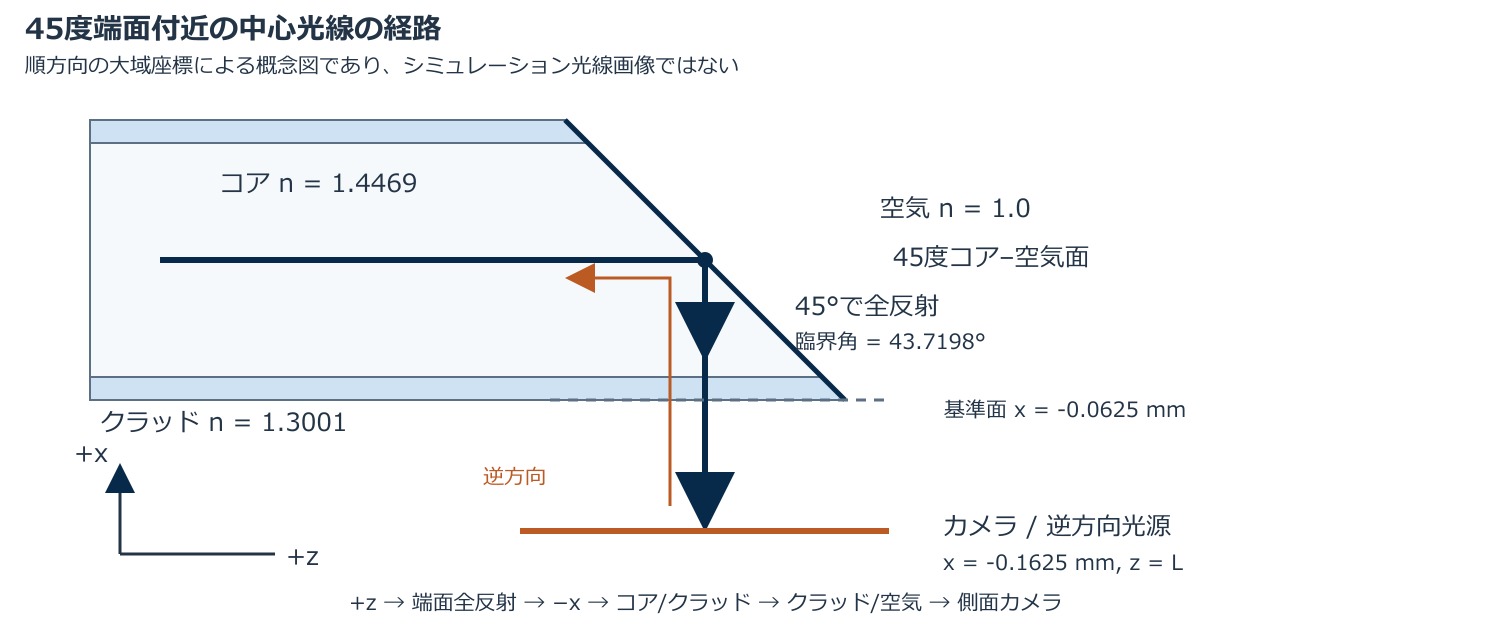

*図2. 45度端面付近の中心光線の概念経路。シミュレーションで得た光線画像ではない。*

既定値の軸上中心光線は+z_fへ進み、法線(1,0,1)/√2のコア端面に45度で入射する。core–airの臨界角はasin(1/1.4469)=43.7198度なので、この代表経路は全反射する。反射方向は−xとなり、続いて円筒状のcore–clad境界とclad–air外壁を透過して側面カメラへ進む。45度端面から直ちに空気へ透過する経路と説明すると、この主要光路を見落とす。

$$
\hat{k}_{refl}=\hat{k}_{in}-2(\hat{k}_{in}\cdot \hat{n})\hat{n},\quad (0,0,1)\rightarrow (-1,0,0)
$$

全光線が同一角度で入射するわけではない。位置と方向に応じて45度面を透過したり、クラッドへ漏れたりする経路も含まれる。core–cladの臨界角は63.9670度、NA=√(n_core²−n_clad²)=0.635027であり、いずれも材料値からの計算値である。これらだけで実際のチャネル到達率や焦点径は決まらない。既定再生は保存された有効チャネルを使用し、選択的analytic分岐もAS_GUIDED_ONLY=Falseなので、NA外成分を事前に全て除いてはいない。

<a id="section-09"></a>

## 9 出射光線を側面基準面へ集める方法

**出典**: [S03 · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28) · [S12 · L1947–L2123](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1947-L2123) · [S13 · L2584–L2739](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2584-L2739) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233)

既定のKRAKEN_CAPTURE_GAP_MM=Noneはfocus_geometryが計算した0.1 mmに置き換わる。幾何追跡の側面capture diskは実際のカメラ中心と同じ位置にあり、半径は0.30 mmである。ただし、その検出点で数えた光線数を最終カメラ画像として使わない。output_detector_sideへ到達した有効記録を選び、光線方向に沿って固定基準面x=−0.0625 mmへ戻してから波動伝搬を行う。

$$
s=-\frac{(r_{det}-c_{ref})\cdot e_w}{\hat{k}\cdot e_w},\quad r_{ref}=r_{det}+s\hat{k}
$$

$$
E_{ref}=E_{det}e^{i k_0 n_{out}s},\quad (u,v)=((r_{ref}-c_{ref})\cdot e_u,(r_{ref}-c_{ref})\cdot e_v)
$$

カメラが基準面より進行方向の前方にある場合、sは負となる。その区間の位相を差し引くので、基準面以後の距離を二重に加算しない。電場と進行方向も局所(u,v,w)へ回転する。検査条件は検出点と状態位置の一致、外部屈折率、k·e_w>0、基準面半幅0.075 mm以内、ゼロ長区間の除外などである。検出面へ到達したことと、最終場の加算に採用されたことは同じではない。

既定phase_conjugate結果のE_referenceとE_cameraは、この側面場である。z方向へ漏れた光線の記録は残るが、軸方向画像は計算しないためE_camera_zなどはNoneとなる。camera_z_mm=Lは側面カメラ中心の大域z座標であり、波が+z軸へ進むことを意味しない。

<a id="section-10"></a>

## 10 有限画素での複素場と強度の加算

**出典**: [S14 · L14–L41](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L14-L41) · [S21 · L651–L673](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L651-L673) · [S22 · L2477–L2582](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2477-L2582)

順方向の側面基準面と逆方向の平坦出射面はaccumulate_fieldを共用する。座標を最寄りの格子節点のセルへ割り当て、光線交点からセル中心までの横方向位相を補正する。面積積分を表す複素場寄与を、総発射数N₀とセル面積Δ²で割って電場を加算する。画素に入った光線数だけで割る平均でも、各光線の強度を先に足す非コヒーレント計算でもない。

$$
\Phi _{jp}=k_0n_{out}\hat{k}_{j,\perp }\cdot (\rho _p-\rho _j)
$$

$$
E_p=\frac{1}{N_0\Delta ^2}\sum_{j\in C_p}W_j E_j e^{i\Phi _{jp}}
$$

$$
H_p=\frac{1}{N_0\Delta ^2}\sum_{j\in C_p}n_{out}(\hat{k}_j\times E_j)W_j e^{i\Phi _{jp}}
$$

$$
I_p=\frac{1}{2}\mathrm{Re}(E_p\times H_p^{*})\cdot e_w
$$

N₀は逆方向で元々発射した総数262144である。既定の順方向再生でも、保存され再入射するチャネル数へ置き換えず、逆方向の元の発射数を分母に使う。analytic分岐では、その実行の位置数と角標本数の積を使う。

磁場はコードの相対単位H=n(k̂×E)で定義される。順方向側面ではe_wが局所第三軸、逆方向平面では+z_rである。光線間の位相差がEとHの加算内で干渉を生むため、この強度は一般に|E|²と等しくない。SIのインピーダンス定数、検出器感度、露光時間、光子数変換を適用したW/m²やカメラcountではない。

これは有限セル上の光線に基づく場の推定である。セル内では局所平面波の位相を使い、各光線の方向情報を格子上の和へ圧縮する。光線数が不足したり分布が偏ったりすると、空セルや大きな統計変動が生じ得る。hit_countやactive_pixelsは、この標本化状態を調べる診断量である。

<a id="section-11"></a>

## 11 基準面からカメラまでのベクトル角スペクトル法

**出典**: [S15 · L2741–L2821](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2741-L2821) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233) · [S28 · L237–L288](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L237-L288) · [S29 · L2824–L2885](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2824-L2885)

propagate_vector_angular_spectrumは512×512の基準面場を2048×2048へゼロ埋めする。画素間隔は保たれるため、paddingは視野と周波数標本間隔を変えるが、元の場の空間分解能を4倍にするわけではない。3成分にcentered FFTを適用し、局所横波数k_u,k_vに対して伝搬可能な成分だけを残す。

$$
k_w=\sqrt{(n_{out}k_0)^2-k_u^2-k_v^2},\quad k_u^2+k_v^2\leq (n_{out}k_0)^2
$$

$$
A_w=-\frac{k_uA_u+k_vA_v}{k_w},\quad A(d)=A(0)e^{i k_w d}
$$

コードはA_u,A_vを保ち、横波条件からA_wを作り直す。入力の第三成分のFFTは上書きされる。コメントの一般的な直交射影という表現より、この実際の演算に基づいて理解すべきである。k_wが10⁻¹⁰ n_out k₀以下のほぼ接線方向の成分とエバネッセント成分は除かれる。したがって、逆方向の距離ゼロ記録面で方向別チャネルをそのまま保持する処理とは異なる。

$$
E_{cam}=\mathcal{F}^{-1}[A(d)],\quad H_{cam}=\mathcal{F}^{-1}[n_{out}(\hat{k}\times A(d))]
$$

伝搬距離d=0.1 mmを適用し、EとHをそれぞれ逆FFTしてI=½Re(E×H*)_wを計算する。最後にカメラ半幅0.20 mmへ切り出す。k_wを放物線近似するFresnel近軸式ではなく、平方根の分散式を使うASMである。ただし一方向の伝搬可能スペクトル、有限窓、離散格子という制限は残る。この関数の実装はNumPy FFTを使う。USE_GPU_NUMERICS=Trueという設定だけでカメラ伝搬がGPU実行されるとはいえない。

保存するforward_camera_angled45.npzには局所座標の複素カメラ場、強度、座標、基準面場、基底、目標点が入る。図の表示では最大強度で割るが、保存した元の強度と正規化画像を混同してはいけない。ピーク位置とその行・列の半値全幅FWHMを強度配列から求める処理であり、多峰性やスペックルを自動的に理想焦点と判定するものではない。

<a id="section-12"></a>

## 12 逆方向点光源のベクトル場と面積標本化

**出典**: [S03 · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28) · [S17 · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136) · [S18 · L317–L367](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L317-L367)

逆方向はカメラの記録画像を読み込んで逆FFTするプログラムではない。順方向の目標点に対応する(−0.1625,0,0) mmへ数学的点光源を置き、傾いたコア面上の標的点を抽出して初期光線方向を作る。半径をa√U、方位角を2πVで抽出するのでxy投影円板上で一様になる。平面の傾斜は一定なので実際の斜面上でも面積密度は一定となり、面積はπa²/cosθである。

$$
\rho =a\sqrt{U},\quad \psi =2\pi V,\quad x=\rho \cos \psi ,\quad y=\rho \sin \psi
$$

$$
z_r=\tan \theta (x\cos \phi +y\sin \phi ),\quad \hat{k}=\frac{r_{target}-r_{src}}{R}
$$

U,Vは[0,1)の一様乱数、Rは光源から標本標的点までの直線距離である。標的点は発射方向を定めるだけで、実際の最初の入射点や45度面との最終交点を強制しない。その前にクラッド外壁で屈折し得るためである。また、全空間の立体角へ一様放射する点光源の全方向を計算する設定でもない。

$$
E_0=J_u e_u+J_v e_v,\quad E_{launch}=\frac{\sqrt{P}A_{facet}}{R}[E_0-\hat{k}(\hat{k}\cdot E_0)]
$$

$$
A_{facet}=\frac{\pi a^2}{\cos \theta },\quad J=(1,0),\quad e_u=(0,1,0),\quad e_v=(0,0,1)
$$

PはSOURCE_POWER=1.0という相対光源スケールであり、この値だけで絶対光出力のワット値を指定したわけではない。

既定Jonesベクトルは光源基底のu直線偏光で、現在の基底では+yである。各光線方向に垂直となるよう射影するが、単位振幅へ再正規化しないため方向依存の振幅が残る。1/Rはコードの球面波振幅モデル、A_facetは面積積分の重みである。1/Nはここでは掛けず、後の画素加算で一度適用する。初期式にexp(i kR)は入れない。光源から実際の各境界までの位相を共通OPL計算が既に加算するためである。

<a id="section-13"></a>

## 13 逆方向の境界通過と出射面記録

**出典**: [S19 · L194–L314](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L194-L314) · [S20 · L369–L482](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L369-L482) · [S21 · L651–L673](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L651-L673) · [S22 · L2477–L2582](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2477-L2582) · [S23 · L44–L64](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L44-L64) · [S31 · L195–L215](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L195-L215)

代表的な中心経路は、側方の空気→クラッド外壁→クラッド→コア境界→45度core–air面での反射→+z_r方向のコア伝搬→平坦なcore–air出射面である。逆方向の斜面法線は順方向法線のz成分を反転したものになる。各実境界では順方向と同じSnell方向計算、s/p Fresnel変換、全反射位相、区間OPL、確率分岐補正を使う。光源位置だけを反対側へ置き、全光線に同じ経路を通らせる単純処理ではない。

逆方向の出射面記録はz_r=Lで空気へ出た直後の場を意味する。数値追跡用に少し前方の補助検出面を置くが、最終チャネルは余分な空気区間を光線ごとに逆伝搬して出射面へ移す。したがってEXIT_CAMERA_DISTANCE_MM=0とは矛盾しない。collect_reference_channelsで有効出射チャネルを集め、accumulate_fieldで加算する。出射面に追加の自由空間ASMを適用しない。

逆方向の最終進行方向は、KrakenのLMNの符号より実際の最後のXYZ区間方向を優先する。最終Eの残留縦成分を除いて保存する。返却E_exitは(3,Ny,Nx)、順方向カメラEは(Ny,Nx,3)で、電場成分の座標系も異なる。amplitude_exitは√Σ|E_c|²、intensity_exitはPoynting fluxなので、両画像を同じ強度として扱ってはいけない。

NPZにはE_exit、x/y座標、光源位置、座標変換文字列、物理パラメータ、方向別の位置・電場・方向・重み・総発射数を保存する。intensity_exitは返却結果にあるが、保存関数のNPZ項目には直接含まれない。mainはファイルが存在しない場合や、パラメータ・格子が一致しない場合に再生を停止する。

<a id="section-14"></a>

## 14 選択可能なanalytic入力分岐

**出典**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S24 · L79–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L79-L136) · [S25 · L1133–L1280](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1133-L1280) · [S26 · L1281–L1403](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1281-L1403) · [S27 · L3067–L3235](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L3067-L3235)

INPUT_MODE=analyticに変更すると、INPUT_FIELD_FUNCTIONのEx,Eyを格子上で評価する。現在の関数はwaist w₀=0.020 mmのGaussian振幅へexp(i2 atan2(y,x))を掛けたx直線偏光場である。ラベルがGaussian input beamでも位相は平坦ではなく、電荷2の渦位相である。ただし振幅へr²因子を含む標準Laguerre–Gaussianモード全体を実装したものではない。コア半径外をマスクし、次式の縦成分を含む前進Poynting積分Pが1となるよう電場全体を1/√P倍する。DはFFT窓の一辺0.15 mmである。

$$
E_x=e^{-(r/w_0)^2}e^{2i\mathrm{atan2}(y,x)},\quad E_y=0
$$

$$
A_{x,y}=\Delta ^2\mathcal{F}[E_{x,y}],\quad A_z=-\frac{k_xA_x+k_yA_y}{k_{z,out}}
$$

$$
P=\frac{1}{D^2}\sum_{prop}\frac{n_{out}k_{z,out}}{2k_{out}}(|A_x|^2+|A_y|^2+|A_z|^2)
$$

2次元FFTで外部angular spectrumを作り、伝搬不能成分を除く。最大ベクトルスペクトル振幅の10⁻³をcutoffとする。各成分の接線波数k_x,k_yを保存してコアのk_zとSnell屈折方向を求め、平坦入射面のs/p Fresnel透過係数を先に適用する。このためanalyticはコア側境界から開始し、既定phase_conjugateは空気側から実際の入射面の確率分岐まで追跡する。

$$
p_m=\frac{\|A_m\|}{\sum_l\|A_l\|},\quad B_m=\frac{A_{core,m}}{p_mD^2}
$$

角成分は外部ベクトル振幅に比例する確率p_mで抽出し、累積分布の層化標本u_m=(m+U_m)/Mを使う。同じbinが複数回選ばれても別々の標本として保持する。A_core,mは入射面透過後のベクトルスペクトルで、コード変数qはこのp_mである。発射位置はコア円板の一様面積標本とする。光線の初期寄与はπa² B_m exp(i(k_xx+k_yy))で与える。現在設定では256個の位置ごとに1024個の角標本を追跡し、262144本を発射する。

その後の内部追跡と場加算は共通関数を使う。ただしanalyticの一般的なutility.run_simulationはzカメラと側面カメラを構成し、E_cameraの既定別名はzカメラを指す。既定位相共役分岐のE_cameraが側面カメラを意味する点と区別する必要がある。

<a id="section-15"></a>

## 15 順方向と逆方向の対応と限界

**出典**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S04 · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93) · [S08 · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728) · [S14 · L14–L41](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L14-L41) · [S15 · L2741–L2821](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2741-L2821) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233) · [S18 · L317–L367](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L317-L367) · [S21 · L651–L673](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L651-L673)

| 比較 | 順方向既定 | 逆方向 |
| --- | --- | --- |
| 入力 | 保存チャネルの位相共役 | 側方ベクトル点光源 |
| 最初の境界 | 平坦air→core | 代表経路air→clad外壁 |
| 45度面 | 側方へ向ける反射 | 軸方向へ向ける反射 |
| 内部 | 幾何経路と複素Jones伝搬 | 同一の局所法則 |
| 記録面 | 側面基準面後0.1 mmのASM | 平坦出射面の直外 |
| 場の座標 | (Ny, Nx, 3), 局所u, v, w | (3, Ny, Nx), 大域x, y, z_r |
| 保存 | forward_camera_angled45.npz | reverse_exit_field_angled45.npz |

同じ光学系の反対向きの伝搬と説明するのは妥当である。ただし全演算が互いの厳密な逆行列であることを意味しない。有限の発射領域と検出視野、反射・透過で失われる経路、有効記録フィルタ、確率標本化、セル加算、ASMのスペクトル切断がある。一つの出射側で収集したチャネルだけを位相共役して再入射するため、全ての外部放射チャネルを同時に時間反転する計算ではない。

ファイバ内部の電場振幅はFresnel係数と初期重みで運ばれ、各区間では位相だけが更新される。この既定の複素場計算には、光線管断面積のJacobianによる振幅更新、焦点通過の独立したMaslov位相、境界のエバネッセント場分布、モード固有値解析、粗さ・非線形効果がない。材料吸収による振幅減衰もこの複素場の再計算には適用しない。検出面で光線を停止するABSORB処理とは区別すべきである。全反射の偏光位相を含むベクトル幾何光学と外部回折計算を接続した近似、と位置付けるのが正確である。

<a id="section-16"></a>

## 16 結果を解釈するときの確認事項

**出典**: [S01 · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248) · [S03 · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28) · [S04 · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93) · [S16 · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233) · [S17 · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136) · [S28 · L237–L288](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L237-L288) · [S29 · L2824–L2885](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2824-L2885) · [S30 · L1–L10](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/_bootstrap.py#L1-L10)

同一ソースのスナップショットでの実行順は、angled45/mmf_angled45_reverse_main.py --no-plots、次にangled45/mmf_angled45_main.py --no-plotsである。_bootstrapは当該フォルダをimport経路の先頭に置き、ルートの同名モジュールとの混在を避ける。物理パラメータ、目標点、格子を変更した場合はreverseファイルを作り直す。本書は実行手順と実装の説明であり、既定の全光線数で再実行して焦点性能を測定した報告ではない。

| 確認対象 | 解釈 |
| --- | --- |
| source_reconstruction_nrms | 保存チャネルと入力格子場の一致 |
| `n_field_hits`と`skipped_*` | 幾何到達と場への採用の区別 |
| `peak_global_mm`と`target_error_um` | 局所ピークを大域座標へ変換した位置誤差 |
| FWHM | ピーク行と列の半値全幅 |
| 強度正規化 | 表示画像と保存元配列を区別 |
| 標本数と格子 | 光線数増加と格子変更を分けて収束確認 |

コメントより実行式を優先すべき点は明確である。現在の入力は位相共役チャネル、カメラのx座標は−0.1625 mm、基準面以後の距離は0.1 mm、出射後の波動伝搬軸は側面w軸である。またカメラFFTはNumPyを用い、横波補正は二つの横成分を保って縦成分を作り直す演算である。これらを反映して初めて、実際に使用された方法を再現可能な形で説明できる。

## 出典索引

以下のリンクは全て同一の解析対象コミットに固定している。masterが後から変更されても引用したコード行は維持される。

**S01 — 順方向の実行分岐**  
[angled45/mmf_angled45_main.py · L228–L248](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L228-L248)

**S02 — 共通の物理パラメータ**  
[angled45/mmf_parameters.py · L6–L33](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_parameters.py#L6-L33)

**S03 — 目標点とカメラ座標**  
[angled45/mmf_focus.py · L5–L28](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_focus.py#L5-L28)

**S04 — 方向チャネルの検証と位相共役**  
[angled45/mmf_phase_channels.py · L21–L93](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L21-L93)

**S05 — 空気中からの再入射と独立追跡**  
[angled45/mmf_phase_channels.py · L100–L165](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L100-L165)

**S06 — 解析的な交点と法線**  
[angled45/mmf_angled_geometry.py · L11–L103](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled_geometry.py#L11-L103)

**S07 — 局所基底とFresnel係数**  
[angled45/mmf_vector_utility.py · L392–L491](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L392-L491)

**S08 — 光路位相とベクトル場の更新**  
[angled45/mmf_vector_utility.py · L493–L728](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L493-L728)

**S09 — 境界イベントごとの偏光計算**  
[angled45/mmf_vector_utility.py · L745–L1099](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L745-L1099)

**S10 — Krakenの確率的分岐**  
[KrakenOS/KrakenSys.py · L1173–L1240](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/KrakenOS/KrakenSys.py#L1173-L1240)

**S11 — 境界両側の媒質判定**  
[angled45/mmf_vector_utility.py · L1856–L1945](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1856-L1945)

**S12 — 光学系と検出面の構成**  
[angled45/mmf_vector_utility.py · L1947–L2123](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1947-L2123)

**S13 — 側面基準面への戻し計算**  
[angled45/mmf_vector_utility.py · L2584–L2739](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2584-L2739)

**S14 — 有限セルでの複素場の加算**  
[angled45/mmf_field.py · L14–L41](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L14-L41)

**S15 — ベクトル角スペクトル伝搬**  
[angled45/mmf_vector_utility.py · L2741–L2821](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2741-L2821)

**S16 — 側面カメラの出力と保存**  
[angled45/mmf_phase_channels.py · L168–L233](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L168-L233)

**S17 — 逆方向光源と距離ゼロの記録面**  
[angled45/mmf_angled45_reverse_main.py · L44–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L44-L136)

**S18 — 点光源の標本と初期電場**  
[angled45/mmf_vector_reverse_utility.py · L317–L367](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L317-L367)

**S19 — 逆方向の媒質と光学系**  
[angled45/mmf_vector_reverse_utility.py · L194–L314](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L194-L314)

**S20 — 逆方向の経路と偏光**  
[angled45/mmf_vector_reverse_utility.py · L369–L482](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L369-L482)

**S21 — 逆方向出射場の再構成**  
[angled45/mmf_vector_reverse_utility.py · L651–L673](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_reverse_utility.py#L651-L673)

**S22 — 出射チャネルの収集と平面場**  
[angled45/mmf_vector_utility.py · L2477–L2582](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2477-L2582)

**S23 — 逆方向NPZの保存**  
[angled45/mmf_field.py · L44–L64](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_field.py#L44-L64)

**S24 — 選択的な解析入力と標本数**  
[angled45/mmf_angled45_main.py · L79–L136](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_main.py#L79-L136)

**S25 — 入力場FFTと縦成分**  
[angled45/mmf_vector_utility.py · L1133–L1280](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1133-L1280)

**S26 — 角成分と位置の重要度標本化**  
[angled45/mmf_vector_utility.py · L1281–L1403](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L1281-L1403)

**S27 — analyticの全体実行経路**  
[angled45/mmf_vector_utility.py · L3067–L3235](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L3067-L3235)

**S28 — 表示の正規化と図の保存**  
[angled45/mmf_phase_channels.py · L237–L288](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_phase_channels.py#L237-L288)

**S29 — ピークとFWHMの計算**  
[angled45/mmf_vector_utility.py · L2824–L2885](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_vector_utility.py#L2824-L2885)

**S30 — 同一フォルダのモジュール優先順位**  
[angled45/_bootstrap.py · L1–L10](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/_bootstrap.py#L1-L10)

**S31 — 逆方向の振幅と強度の区別**  
[angled45/mmf_angled45_reverse_main.py · L195–L215](https://github.com/z-labo/Raytracing/blob/c6a399ce07fd095daee3bedfee1fb04ccac07f4d/angled45/mmf_angled45_reverse_main.py#L195-L215)